⚙️ Using device: cpu
✅ Model loaded successfully!
🖼️ Real image prediction:


d:\AI Mini project (AI vs Real image)\venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\AI Mini project (AI vs Real image)\venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


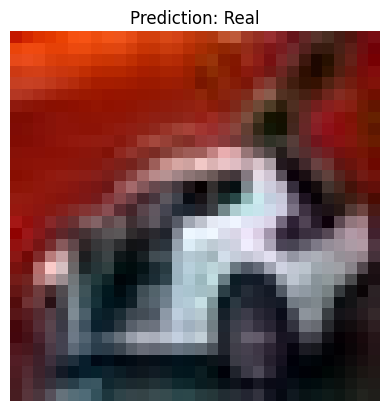


🤖 AI image prediction:


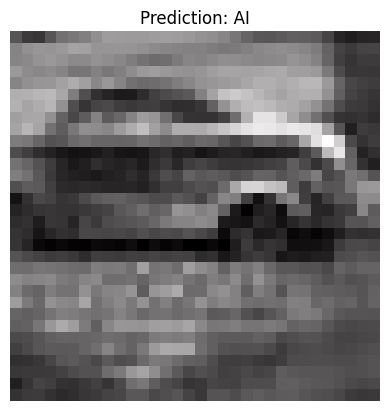


✅ Results:
Real image → Real
AI image → AI


In [1]:
# %% --- Imports ---
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import os

# %% --- Device setup ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("⚙️ Using device:", device)

# %% --- Same transform as training ---
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # consistent normalization
])

# %% --- Recreate model architecture ---
model = models.resnet18(pretrained=False)
num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(num_features, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, 2)  # 2 classes: AI=0, REAL=1
)
model = model.to(device)

# %% --- Load trained weights ---
model.load_state_dict(torch.load("resnet18_cifake_classifier.pth", map_location=device))
model.eval()
print("✅ Model loaded successfully!")

# %% --- Prediction function ---
def predict_image(img_path):
    # Load and preprocess image
    image = Image.open(img_path).convert("RGB")
    img_tensor = transform(image).unsqueeze(0).to(device)

    # Model prediction
    with torch.no_grad():
        output = model(img_tensor)
        pred = torch.argmax(output, 1).item()

    # Correct label order based on ImageFolder alphabetical order (AI=0, REAL=1)
    labels = ["AI", "Real"]
    predicted_label = labels[pred]

    # Display image and prediction
    plt.imshow(np.array(image))
    plt.title(f"Prediction: {predicted_label}")
    plt.axis("off")
    plt.show()

    return predicted_label

# %% --- Paths to test images ---
# ⚠️ Change these two paths to actual test image locations on your system
real_image_path = r"D:\AI Mini project (AI vs Real image)\archive\test\REAL\0000 (2).jpg"
fake_image_path = r"D:\AI Mini project (AI vs Real image)\archive\test\FAKE\0 (2).jpg"

# %% --- Run predictions ---
print("🖼️ Real image prediction:")
real_pred = predict_image(real_image_path)

print("\n🤖 AI image prediction:")
fake_pred = predict_image(fake_image_path)

print(f"\n✅ Results:\nReal image → {real_pred}\nAI image → {fake_pred}")


Running on: cpu
✅ Model loaded successfully!
Classes: ['FAKE', 'REAL']


Evaluating: 100%|██████████| 625/625 [06:38<00:00,  1.57it/s]



📊 Model Performance Metrics:
✅ Accuracy:  90.18%
🎯 Precision: 0.9020
🔁 Recall:    0.9018
💡 F1 Score:  0.9018


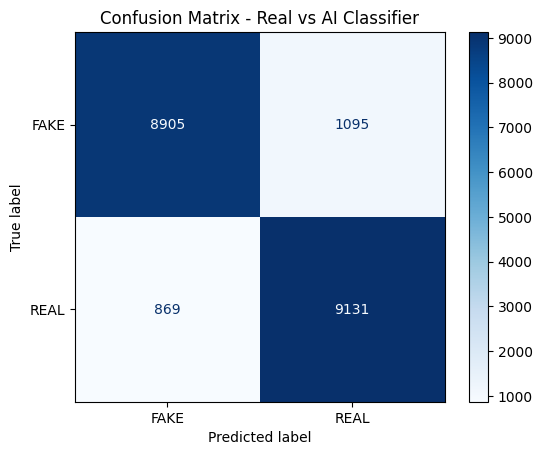

In [5]:
import torch
import torch.nn as nn
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from tqdm import tqdm
import matplotlib.pyplot as plt

# ---- Device ----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Running on:", device)

# ---- Model definition (MUST match training) ----
model = models.resnet18(pretrained=False)
num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(num_features, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, 2),
    nn.Softmax(dim=1)
)
model = model.to(device)

# ---- Load weights ----
model.load_state_dict(torch.load(
    r"D:\AI Mini project (AI vs Real image)\resnet18_cifake_classifier.pth",
    map_location=device
))
model.eval()
print("✅ Model loaded successfully!")

# ---- Transform (MUST match training) ----
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# ---- Load Test Dataset ----
test_dir = r"D:\AI Mini project (AI vs Real image)\archive\test"
test_data = datasets.ImageFolder(root=test_dir, transform=transform)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)
class_names = list(test_data.class_to_idx.keys())
print("Classes:", class_names)

# ---- Evaluate ----
y_true, y_pred = [], []

with torch.no_grad():
    for X, y in tqdm(test_loader, desc="Evaluating"):
        X, y = X.to(device), y.to(device)
        preds = model(X).argmax(1)
        y_true.extend(y.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# ---- Metrics ----
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted')
rec = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print("\n📊 Model Performance Metrics:")
print(f"✅ Accuracy:  {acc*100:.2f}%")
print(f"🎯 Precision: {prec:.4f}")
print(f"🔁 Recall:    {rec:.4f}")
print(f"💡 F1 Score:  {f1:.4f}")

# ---- Confusion Matrix ----
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Real vs AI Classifier")
plt.show()


